### **Experiments for N-dim convex optimization problem**

We have trained more adaptive learning rate (LR) models for Gradient Descent models to be used in higher dimensions: **[5, 10, 100, 800]**

800 is the maximum value because we need the measurement to align with the number of parameters in the MNIST problem

In [1]:
import gymnasium as gym
import src.gymnasium_envs.convex_optimization_env
import src.utils.exps_utils as exps

seed = 42
max_iterations = 10000

env_id = "convex_optimization_env/ConvexOptimization-v1"

available_dims = [2, 5, 10, 100]

base_env_kwargs = {
    
}

### 1. Convergence on [2, 5, 10, 100] vs. ADAM and GD 

Let's build convergence graphs for models trained on a specific dimension

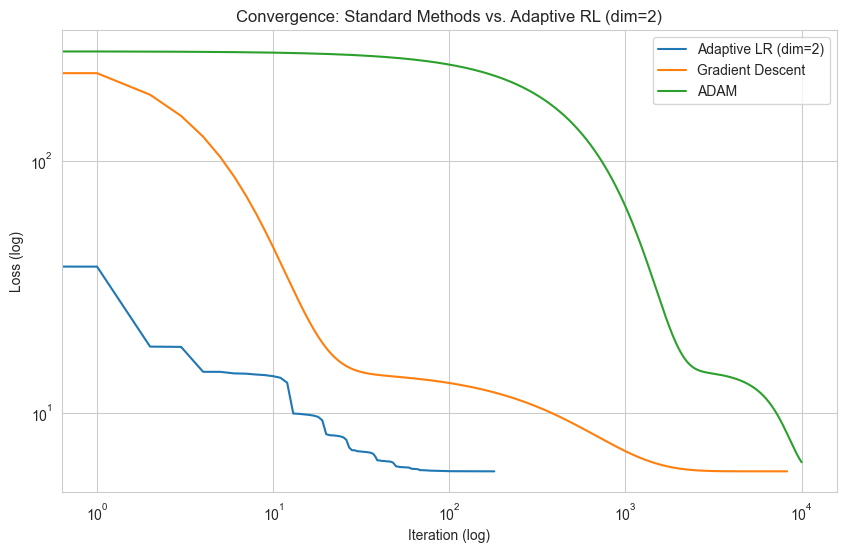

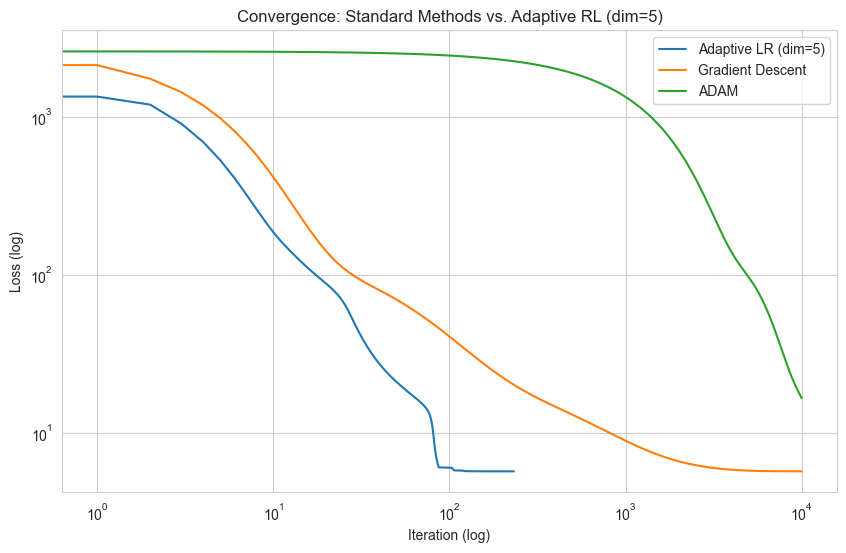

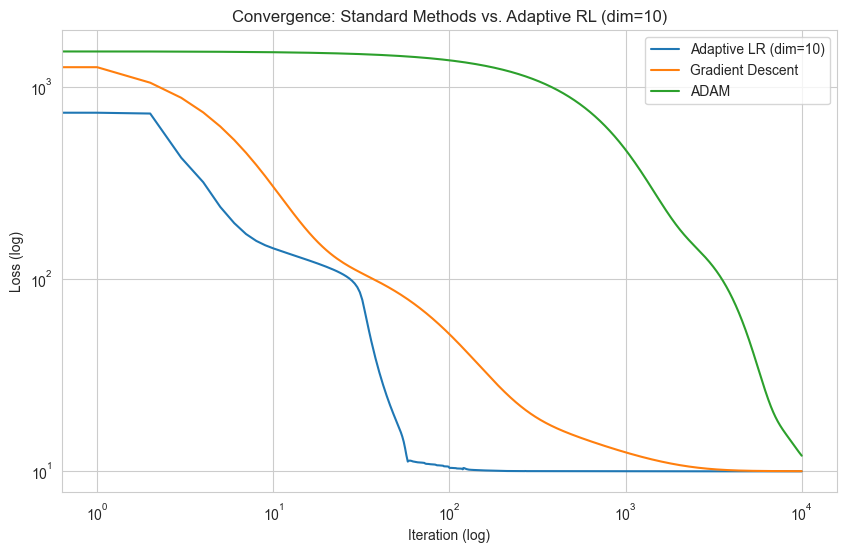

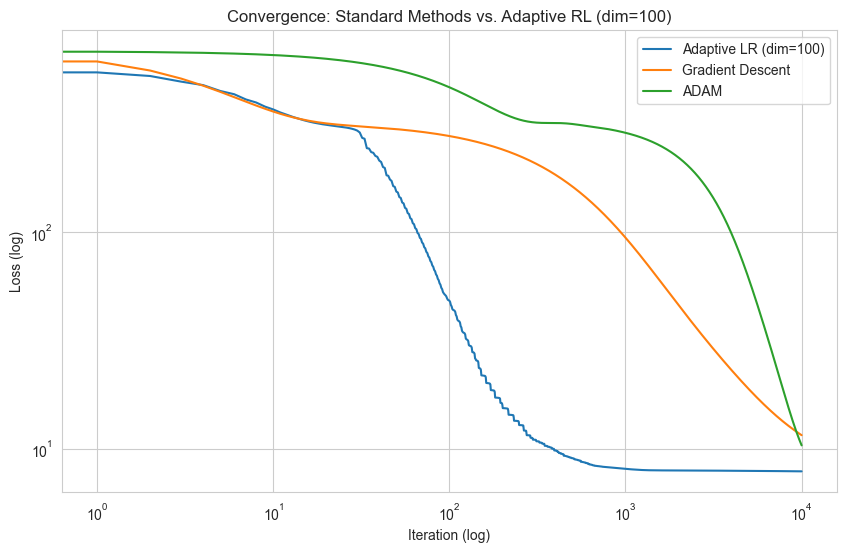

In [2]:
for dim in available_dims:
    stats = f"../models/{dim}d_convex_vec_normalize.pkl"
    model = f"../models/{dim}d_convex"
    
    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)
    model_dir = exps.get_model_dir(stats, model)

    result_rl, x0, function = exps.optimize_exp_rl(method=f"Adaptive LR (dim={dim})", env_config=env_config, model_dir=model_dir)
    result_gdesc = exps.optimize_exp_standart(method="GD", x0=x0, function=function, env_config=env_config)
    result_adam = exps.optimize_exp_standart(method="ADAM", x0=x0, function=function, env_config=env_config)
    
    result = result_rl | result_gdesc | result_adam

    exps.plot_converging_comparasion(result, dim, title=f"Convergence: Standard Methods vs. Adaptive RL (dim={dim})")
    

### 2. Distribution of the number of iterations on [2, 5, 10, 100] vs. ADAM and GD

Let's build tables with statistical characteristics of the iteration distribution.

In [3]:
sample_count = 10

for dim in available_dims:
    print(f"Distribution of iterations number on {dim}-dim convex problem")

    stats = f"../models/{dim}d_convex_vec_normalize.pkl"
    model = f"../models/{dim}d_convex"
    
    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)
    model_dir = exps.get_model_dir(stats, model)

    stats = exps.plot_iterations_distribution_vs_standart(sample_count=sample_count, env_config=env_config, model_dir=model_dir)

    display(stats)

Distribution of iterations number on 2-dim convex problem


,mean,variance,std,min,max,range
Adaptive LR (dim=2),130.9,10202.69,101.01,23.0,291.0,268.0
Gradient Descent,5375.0,14868810.60,3856.01,311.0,10001.0,9690.0
ADAM,9583.7,793023.21,890.52,7220.0,10001.0,2781.0


Distribution of iterations number on 5-dim convex problem


,mean,variance,std,min,max,range
Adaptive LR (dim=5),1368.7,8288720.21,2879.01,175.0,9999.0,9824.0
Gradient Descent,9937.2,36633.96,191.40,9363.0,10001.0,638.0
ADAM,10001.0,0.00,0.00,10001.0,10001.0,0.0


Distribution of iterations number on 10-dim convex problem


,mean,variance,std,min,max,range
Adaptive LR (dim=10),8191.9,13092939.69,3618.42,573.0,9999.0,9426.0
Gradient Descent,10001.0,0.00,0.00,10001.0,10001.0,0.0
ADAM,10001.0,0.00,0.00,10001.0,10001.0,0.0


Distribution of iterations number on 100-dim convex problem


,mean,variance,std,min,max,range
Adaptive LR (dim=100),9999.0,0.0,0.0,9999.0,9999.0,0.0
Gradient Descent,10001.0,0.0,0.0,10001.0,10001.0,0.0
ADAM,10001.0,0.0,0.0,10001.0,10001.0,0.0


### 3. Convergence for different function scale parameter

For fixed dim = 5, let's compare the convergence of standard methods and adaptive LR on different scale parameters.

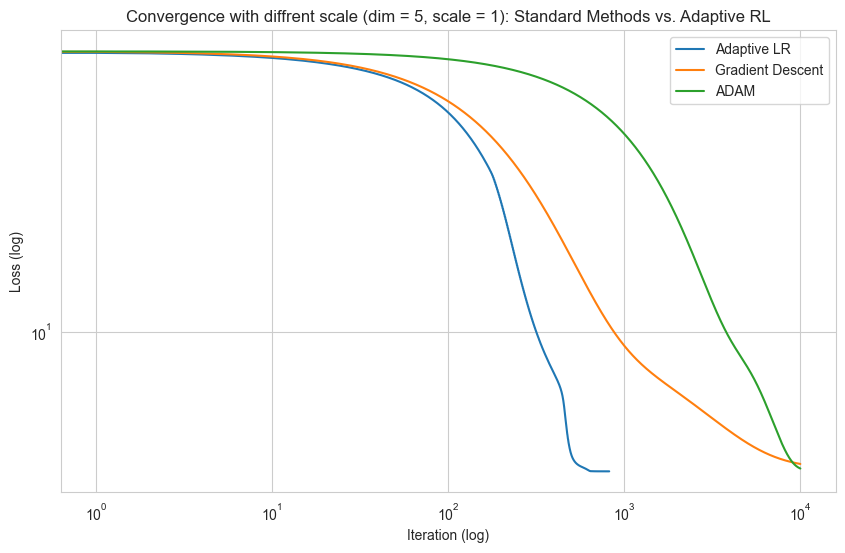

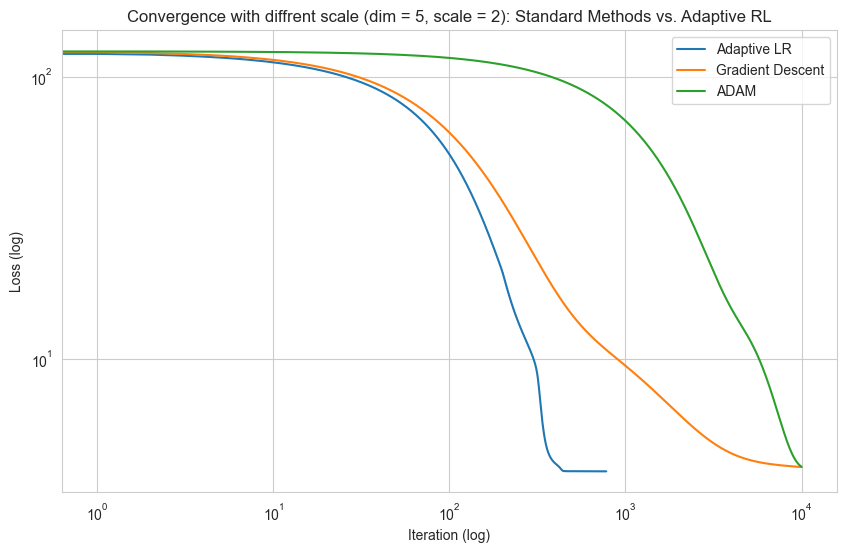

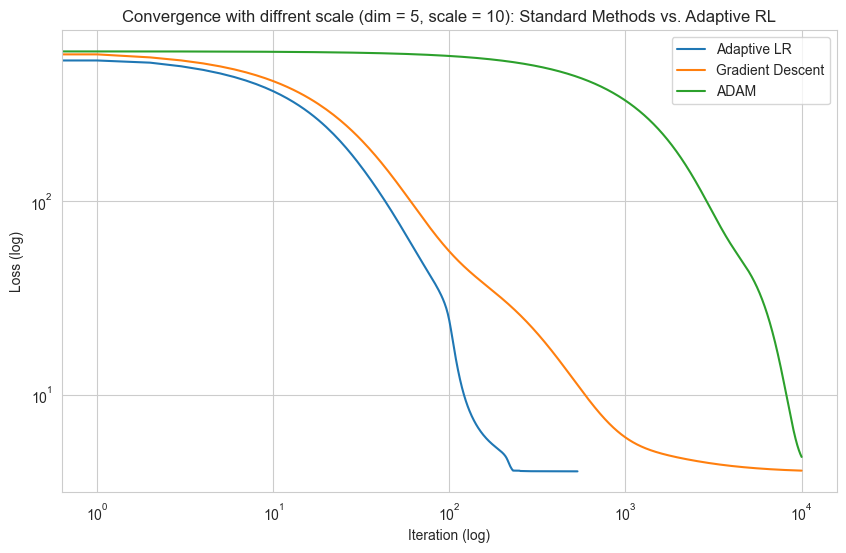

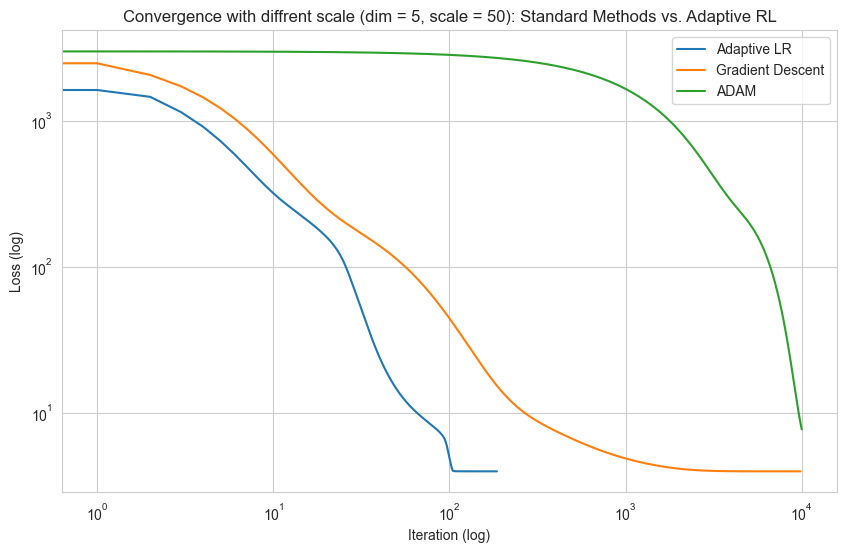

In [4]:
scales = [1, 2, 10, 50]

fixed_dim = 5

for scale in scales:
    stats = f"../models/{fixed_dim}d_convex_vec_normalize.pkl"
    model = f"../models/{fixed_dim}d_convex"
    
    env_kwargs = base_env_kwargs
    env_kwargs["scale"] = scale

    env_config = exps.get_env_config(seed, fixed_dim, max_iterations, env_id, env_kwargs=env_kwargs)
    model_dir = exps.get_model_dir(stats, model)

    result_rl, x0, function = exps.optimize_exp_rl(method=f"Adaptive LR", env_config=env_config, model_dir=model_dir)
    result_gdesc = exps.optimize_exp_standart(method="GD", x0=x0, function=function, env_config=env_config)
    result_adam = exps.optimize_exp_standart(method="ADAM", x0=x0, function=function, env_config=env_config)
    
    result = result_rl | result_gdesc | result_adam

    exps.plot_converging_comparasion(result, fixed_dim, title=f"Convergence with diffrent scale (dim = {fixed_dim}, scale = {scale}): Standard Methods vs. Adaptive RL")

### 4. Early stop by metric vs the usual model

Let's compare the usual model against an early stop in terms of the average number of steps.

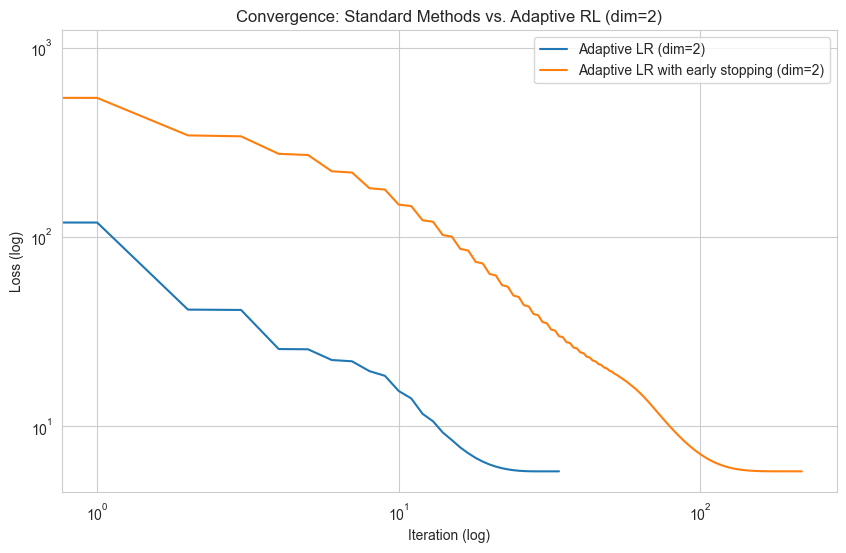

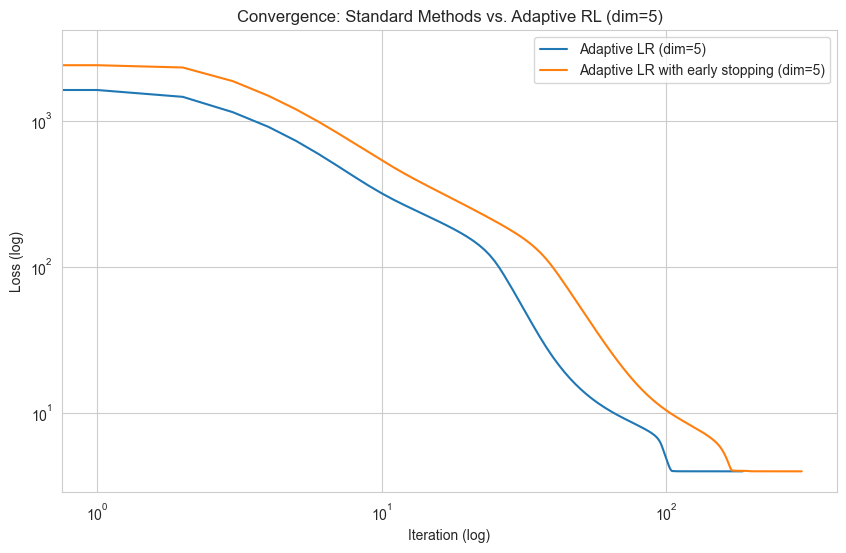

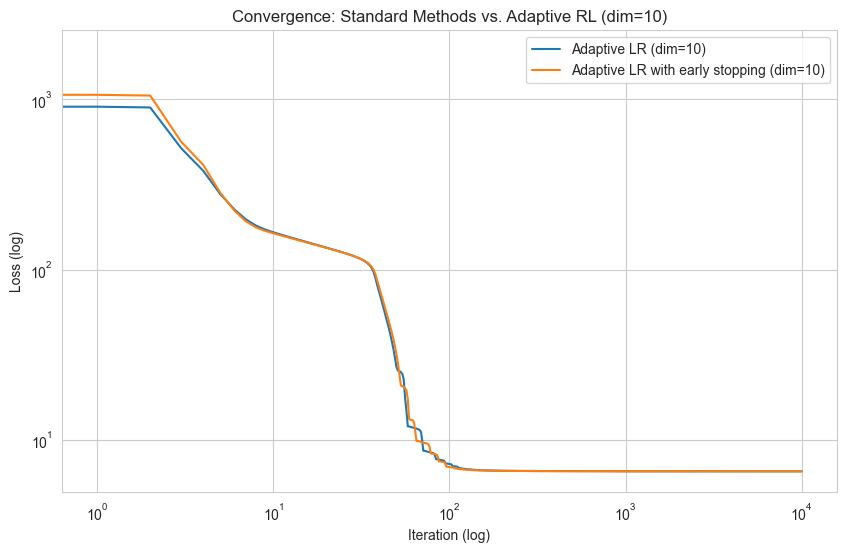

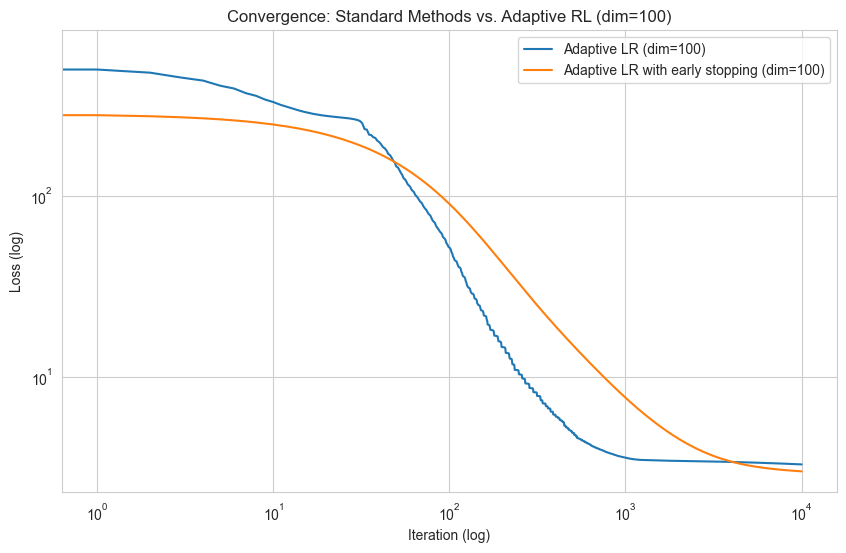

In [5]:
for dim in available_dims:
    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)

    stats_defualt = f"../models/{dim}d_convex_vec_normalize.pkl"
    model_defualt = f"../models/{dim}d_convex"
    model_dir_defualt = exps.get_model_dir(stats_defualt, model_defualt)
    

    stats_early_stopping = f"../models/{dim}d_convex_best/best_vec_normalize.pkl"
    model_early_stopping = f"../models/{dim}d_convex_best/best_model"
    model_dir_early_stopping = exps.get_model_dir(stats_early_stopping, model_early_stopping)

    result_default, x0, function = exps.optimize_exp_rl(method=f"Adaptive LR (dim={dim})", env_config=env_config, model_dir=model_dir_defualt)
    result_early_stopping, x0, function = exps.optimize_exp_rl(method=f"Adaptive LR with early stopping (dim={dim})", env_config=env_config, model_dir=model_dir_early_stopping)

    result = result_default | result_early_stopping

    exps.plot_converging_comparasion(result, dim, title=f"Convergence: Standard Methods vs. Adaptive RL (dim={dim})")
    

### 5. Random dimension model vs. fixed dimension model

Let's compare a model trained on an environment with a random dimension against a model trained on an environment with a fixed dimension

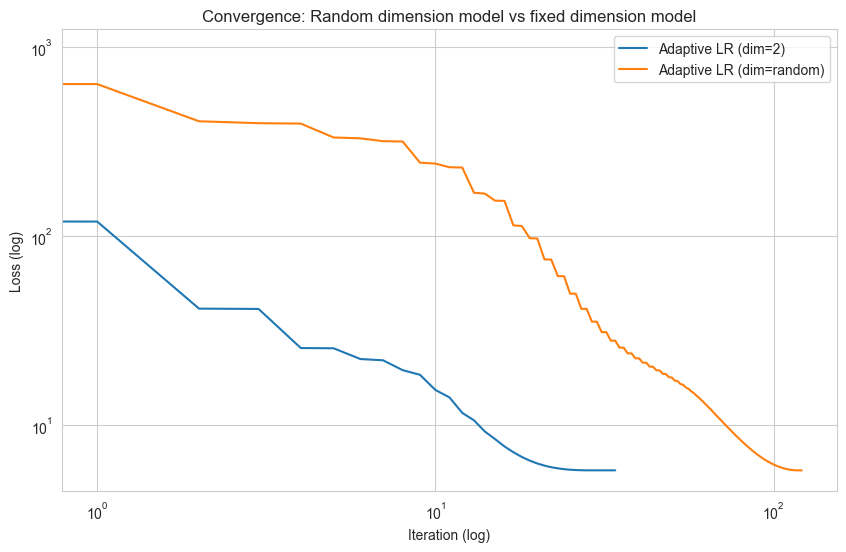

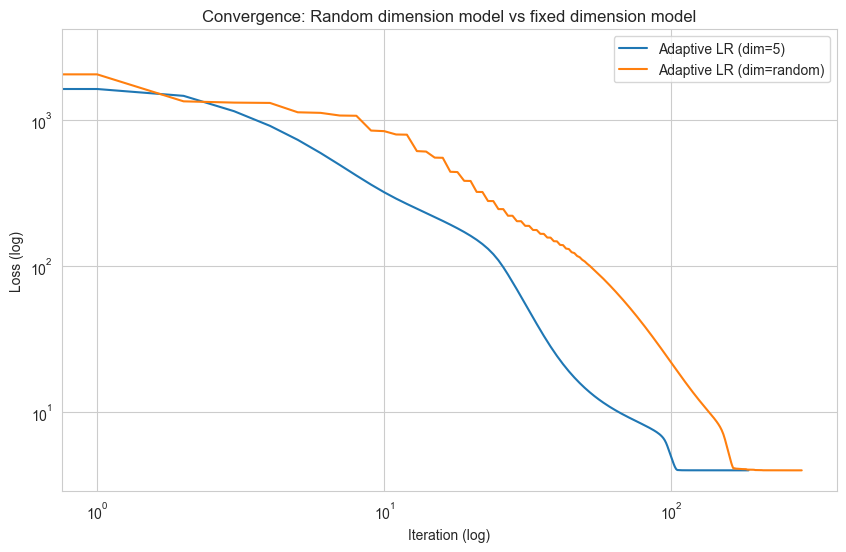

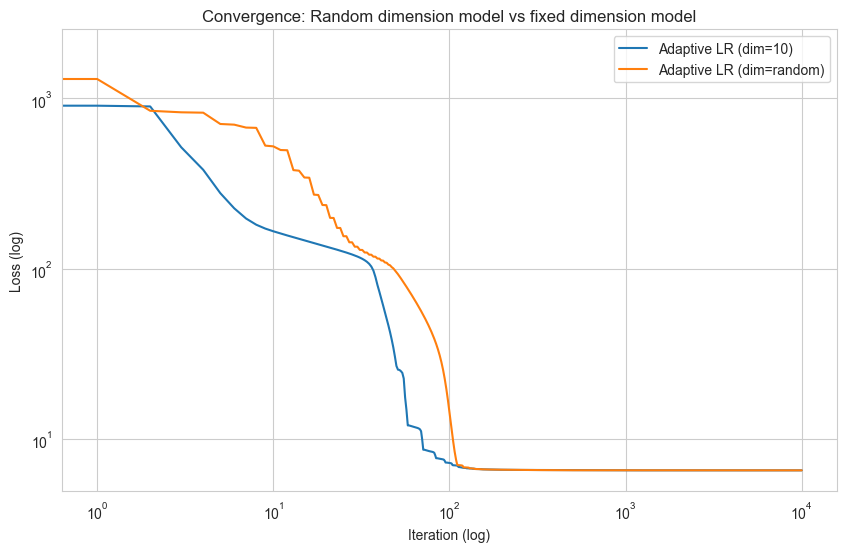

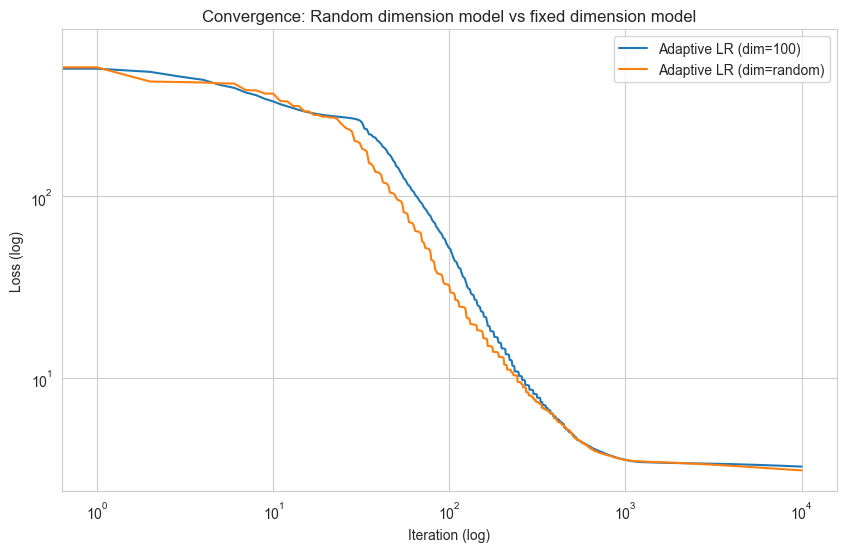

In [6]:
for dim in available_dims:
    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)

    stats_defualt = f"../models/{dim}d_convex_vec_normalize.pkl"
    model_defualt = f"../models/{dim}d_convex"
    model_dir_defualt = exps.get_model_dir(stats_defualt, model_defualt)
    
    stats_any_dim = "../models/anyd_convex_vec_normalize.pkl"
    model_any_dim = "../models/anyd_convex"
    model_dir_any_dim = exps.get_model_dir(stats_any_dim, model_any_dim)

    result_default, x0, function = exps.optimize_exp_rl(method=f"Adaptive LR (dim={dim})", env_config=env_config, model_dir=model_dir_defualt)
    result_any_d, x0, function = exps.optimize_exp_rl(method="Adaptive LR (dim=random)", env_config=env_config, model_dir=model_dir_any_dim)

    result = result_default | result_any_d

    exps.plot_converging_comparasion(result, dim, title=f"Convergence: Random dimension model vs fixed dimension model")
    

### 6. Distribution of the number of iterations random dim vs. fixed dim

In [7]:
sample_count = 10

for dim in available_dims:
    print(f"Distribution of iterations number random dim vs fixed dim = {dim}")

    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)
    
    stats_defualt = f"../models/{dim}d_convex_vec_normalize.pkl"
    model_defualt = f"../models/{dim}d_convex"
    model_dir_default = exps.get_model_dir(stats_defualt, model_defualt)

    stats_any_dim = "../models/anyd_convex_vec_normalize.pkl"
    model_any_dim = "../models/anyd_convex"
    model_dir_any_dim = exps.get_model_dir(stats_any_dim, model_any_dim)

    models = {
        f"Adaptive LR (dim={dim})" : model_dir_default,
        "Adaptive LR (dim=random)" : model_dir_any_dim
    }

    stats = exps.plot_iterations_distribution(sample_count=sample_count, env_config=env_config, models=models)

    display(stats)

Distribution of iterations number random dim vs fixed dim = 2


,mean,variance,std,min,max,range
Adaptive LR (dim=2),110.6,2720.04,52.15,36.0,211.0,175.0
Adaptive LR (dim=random),191.7,4323.21,65.75,116.0,367.0,251.0


Distribution of iterations number random dim vs fixed dim = 5


,mean,variance,std,min,max,range
Adaptive LR (dim=5),375.1,14357.09,119.82,197.0,570.0,373.0
Adaptive LR (dim=random),1430.1,1632256.09,1277.60,373.0,4914.0,4541.0


Distribution of iterations number random dim vs fixed dim = 10


,mean,variance,std,min,max,range
Adaptive LR (dim=10),7403.4,15747154.04,3968.27,1116.0,9999.0,8883.0
Adaptive LR (dim=random),8202.7,10362247.21,3219.04,1389.0,9999.0,8610.0


Distribution of iterations number random dim vs fixed dim = 100


,mean,variance,std,min,max,range
Adaptive LR (dim=100),9999.0,0.0,0.0,9999.0,9999.0,0.0
Adaptive LR (dim=random),9999.0,0.0,0.0,9999.0,9999.0,0.0


### 7. Adding a time penalty on the convergence of a random dimension model

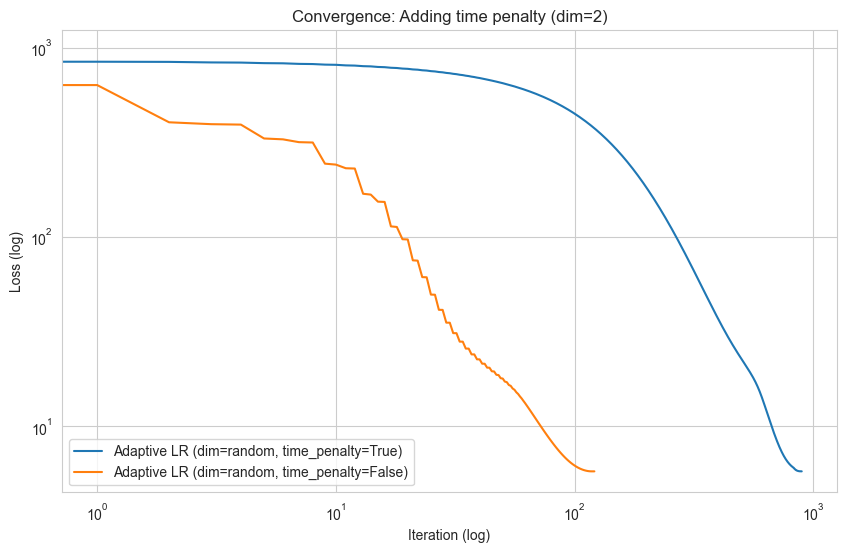

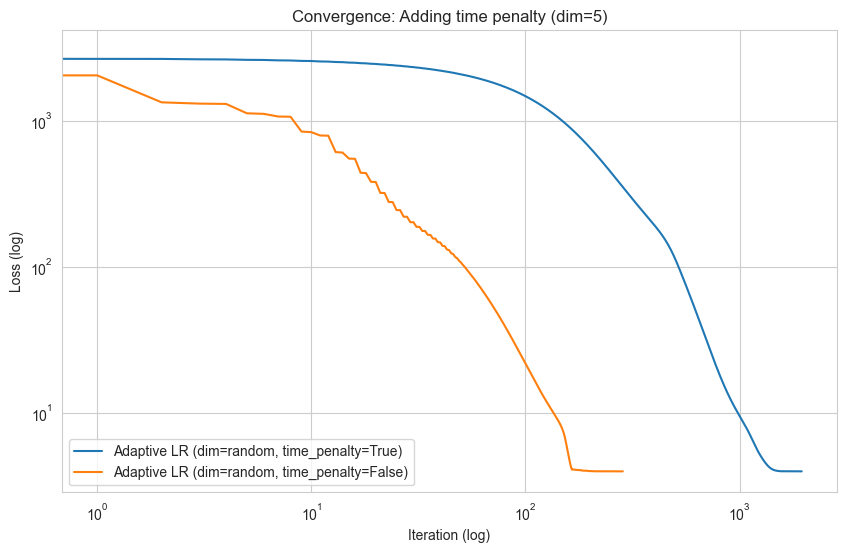

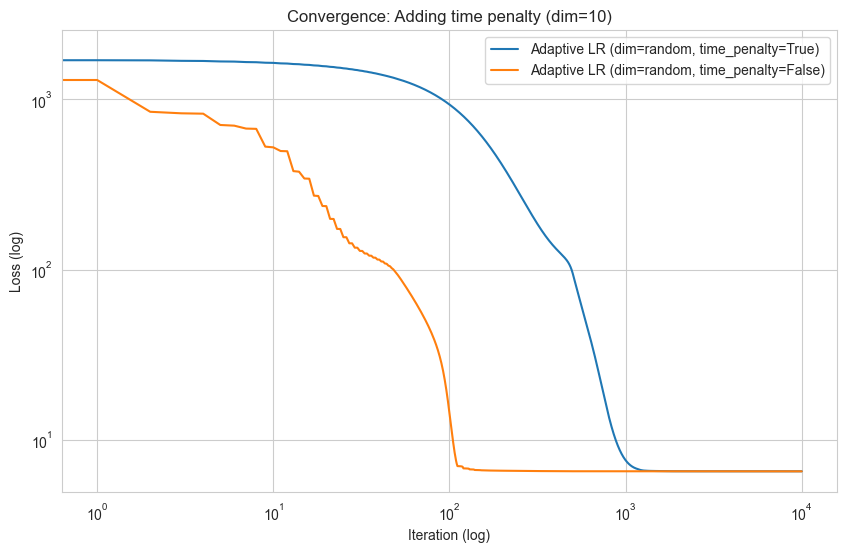

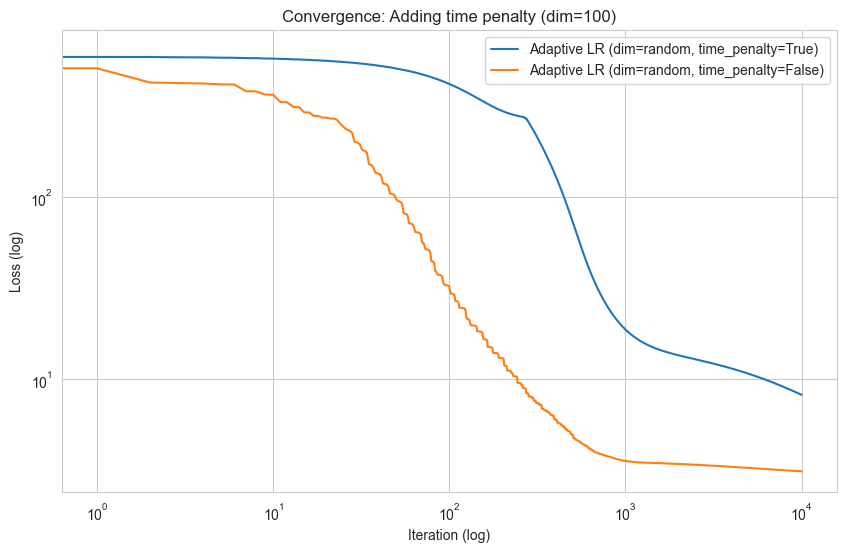

In [8]:
for dim in available_dims:
    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)

    stats_time_penalty = f"../models/time_penalty_anyd_convex_vec_normalize.pkl"
    model_time_penalty = f"../models/time_penalty_anyd_convex"
    model_dir_time_penalty = exps.get_model_dir(stats_time_penalty, model_time_penalty)

    stats_any_dim = "../models/anyd_convex_vec_normalize.pkl"
    model_any_dim = "../models/anyd_convex"
    model_dir_any_dim = exps.get_model_dir(stats_any_dim, model_any_dim)

    result_time_penalty, x0, function = exps.optimize_exp_rl(method=f"Adaptive LR (dim=random, time_penalty=True)", env_config=env_config, model_dir=model_dir_time_penalty)
    result_any_d, x0, function = exps.optimize_exp_rl(method="Adaptive LR (dim=random, time_penalty=False)", env_config=env_config, model_dir=model_dir_any_dim)

    result = result_time_penalty | result_any_d

    exps.plot_converging_comparasion(result, dim, title=f"Convergence: Adding time penalty (dim={dim})")
    